# Lab 6. Naive Bayes and Text Classification

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-06-naive-bayes-text-classification.ipynb)

This lab accompanies Chapter 6 of **Mathematical Natural Language Processing**.

In this lab, we build a transparent text classifier from first principles:

$$
\text{labeled text} \longrightarrow \text{token counts} \longrightarrow \text{probabilities} \longrightarrow \text{log-scores} \longrightarrow \text{predictions}.
$$

The main model is **multinomial Naive Bayes**. It is not a large language model, but it is one of the clearest mathematical baselines in NLP. It shows how Bayes' theorem, count vectors, smoothing, and linear decision rules fit together.

## How to use this lab

1. Read the explanation before each code cell.
2. Run all cells in order.
3. Inspect the printed tables and plots.
4. When you see **Try it yourself**, modify the code and rerun the cell.
5. Complete the exercises and mini-project at the end.

The lab uses standard Python tools: `numpy`, `pandas`, `matplotlib`, and a small optional comparison with `scikit-learn`. Everything should run directly in Google Colab.

## Learning goals

After completing this lab, you should be able to:

- formulate text classification as a supervised learning problem;
- explain the Bayes decision rule under zero-one loss;
- represent documents as count vectors;
- estimate class priors and class-conditional token probabilities;
- implement multinomial Naive Bayes from scratch;
- explain why add-alpha smoothing is necessary;
- compute log-scores instead of multiplying tiny probabilities;
- interpret log-odds token weights;
- evaluate a classifier using a confusion matrix, precision, recall, and F1 score;
- compare Naive Bayes with logistic regression;
- audit model behavior by inspecting feature weights and errors.

## 1. Mathematical background

A text classification dataset consists of pairs

$$
(d_i,y_i), \qquad i=1,\ldots,n,
$$

where $d_i$ is a document and $y_i$ is a label. After choosing a vocabulary

$$
V=\{v_1,\ldots,v_m\},
$$

we represent a document by a count vector

$$
x=(x_1,\ldots,x_m),
$$

where $x_j$ is the number of times token $v_j$ appears in the document.

The Bayes decision rule chooses the class with the largest posterior probability:

$$
\widehat y = \arg\max_c P(Y=c \mid X=x).
$$

By Bayes' theorem, the denominator does not depend on $c$, so classification can use

$$
\widehat y = \arg\max_c P(X=x \mid Y=c)P(Y=c).
$$

Multinomial Naive Bayes assumes that, within a class, tokens are generated from a class-specific token distribution

$$
\theta_c=(\theta_{c1},\ldots,\theta_{cm}), \qquad \sum_{j=1}^m \theta_{cj}=1.
$$

For a document count vector $x$, the class score is proportional to

$$
\pi_c \prod_{j=1}^m \theta_{cj}^{x_j},
$$

where $\pi_c=P(Y=c)$ is the class prior.

Because products of many small probabilities can underflow numerically, we use log-scores:

$$
s_c(x)=\log \pi_c + \sum_{j=1}^m x_j \log \theta_{cj}.
$$

The prediction is

$$
\widehat y = \arg\max_c s_c(x).
$$

## 2. Why smoothing is necessary

The maximum likelihood estimate for token probabilities is

$$
\widehat\theta_{cj}=\frac{N_{cj}}{N_c},
$$

where $N_{cj}$ is the number of times token $v_j$ appears in training documents of class $c$, and $N_c$ is the total number of tokens in class $c$.

If $N_{cj}=0$, then $\widehat\theta_{cj}=0$. One unseen token can force the whole class likelihood to zero. Add-alpha smoothing fixes this:

$$
\widehat\theta_{cj}^{(\alpha)}=\frac{N_{cj}+\alpha}{N_c+\alpha m}, \qquad \alpha>0.
$$

The parameter $\alpha$ controls how strongly the estimate is pulled away from zero. The common choice $\alpha=1$ is called Laplace smoothing.

## 3. Setup

We begin with imports and a small tokenizer. The tokenizer is intentionally simple so that the mathematical structure remains visible.

In [1]:
import re
import math
from collections import Counter, defaultdict
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.max_columns", 80)

rng = np.random.default_rng(7243)

def tokenize(text):
    """Lowercase tokenizer that keeps alphabetic words and apostrophes."""
    return re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())

print(tokenize("Don't ignore Bayes' theorem in NLP!"))

["don't", 'ignore', 'bayes', 'theorem', 'in', 'nlp']


## 4. A small independent-study dataset

We will classify short student-style questions into three categories:

- `transfer`: questions about transfer credit;
- `registration`: questions about course registration and prerequisites;
- `career`: questions about jobs, co-op, resumes, and internships.

The dataset is synthetic, small, and easy to inspect. This is useful for learning. In a real NLP project, you would need more examples and a careful train/test split.

In [2]:
train_data = [
    ("Can I transfer credits from another university", "transfer"),
    ("How many transfer credits can count toward the degree", "transfer"),
    ("I completed a probability course elsewhere can it transfer", "transfer"),
    ("Does this online linear algebra class count as transfer credit", "transfer"),
    ("What documents are needed for transfer credit evaluation", "transfer"),
    ("Can graduate courses from my previous college transfer", "transfer"),
    ("I want to register for machine learning next semester", "registration"),
    ("Which prerequisite do I need before statistical learning", "registration"),
    ("The course is full how do I join the waitlist", "registration"),
    ("Can I take stochastic processes before probability theory", "registration"),
    ("When does registration open for spring classes", "registration"),
    ("Do I need permission to enroll in this course", "registration"),
    ("How can I prepare my resume for data science internships", "career"),
    ("What courses help with co op and industry jobs", "career"),
    ("Can you recommend projects for a machine learning portfolio", "career"),
    ("How should I search for quantitative analyst positions", "career"),
    ("I want career advice for applying to data scientist roles", "career"),
    ("What skills are useful for math students seeking internships", "career"),
]

test_data = [
    ("Can my previous college probability course transfer", "transfer"),
    ("How do I enroll in machine learning if the class is full", "registration"),
    ("What projects should I put in a data science portfolio", "career"),
    ("Do transfer credits require official documents", "transfer"),
    ("Which prerequisite is required for stochastic processes", "registration"),
    ("How do I find internships for quantitative roles", "career"),
]

labels = sorted({label for _, label in train_data})
print("Labels:", labels)
print("Training examples:", len(train_data))
print("Test examples:", len(test_data))

pd.DataFrame(train_data, columns=["text", "label"]).head(9)

Labels: ['career', 'registration', 'transfer']
Training examples: 18
Test examples: 6


,text,label
0,Can I transfer credits from another university,transfer
1,How many transfer credits can count toward the degree,transfer
2,I completed a probability course elsewhere can it transfer,transfer
3,Does this online linear algebra class count as transfer credit,transfer
4,What documents are needed for transfer credit evaluation,transfer
5,Can graduate courses from my previous college transfer,transfer
6,I want to register for machine learning next semester,registration
7,Which prerequisite do I need before statistical learning,registration
8,The course is full how do I join the waitlist,registration


## 5. Build the vocabulary and count matrix

A vocabulary maps tokens to column indices. The document-term matrix has one row per document and one column per token.

For training example $i$ and vocabulary token $v_j$, the matrix entry is

$$
X_{ij}=\text{number of times token } v_j \text{ appears in document } i.
$$

In [3]:
def build_vocabulary(texts, min_count=1):
    counts = Counter(tok for text in texts for tok in tokenize(text))
    vocab = sorted([tok for tok, count in counts.items() if count >= min_count])
    token_to_index = {tok: j for j, tok in enumerate(vocab)}
    return vocab, token_to_index, counts

def vectorize(texts, token_to_index):
    X = np.zeros((len(texts), len(token_to_index)), dtype=float)
    for i, text in enumerate(texts):
        for tok in tokenize(text):
            if tok in token_to_index:
                X[i, token_to_index[tok]] += 1.0
    return X

train_texts = [text for text, label in train_data]
train_labels = np.array([label for text, label in train_data])
test_texts = [text for text, label in test_data]
test_labels = np.array([label for text, label in test_data])

vocab, token_to_index, token_counts = build_vocabulary(train_texts, min_count=1)
X_train = vectorize(train_texts, token_to_index)
X_test = vectorize(test_texts, token_to_index)

print("Vocabulary size:", len(vocab))
print("First 30 vocabulary tokens:", vocab[:30])
print("X_train shape:", X_train.shape)

pd.DataFrame(X_train[:6, :20], columns=vocab[:20])

Vocabulary size: 98
First 30 vocabulary tokens: ['a', 'advice', 'algebra', 'analyst', 'and', 'another', 'applying', 'are', 'as', 'before', 'can', 'career', 'class', 'classes', 'co', 'college', 'completed', 'count', 'course', 'courses', 'credit', 'credits', 'data', 'degree', 'do', 'documents', 'does', 'elsewhere', 'enroll', 'evaluation']
X_train shape: (18, 98)


,a,advice,algebra,analyst,and,another,applying,are,as,before,can,career,class,classes,co,college,completed,count,course,courses
0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


### Try it yourself

Change `min_count=1` to `min_count=2` in the previous cell. What happens to the vocabulary size? Which rare words disappear? Then change it back to `1` before continuing.

## 6. Train multinomial Naive Bayes from scratch

For each class $c$, we estimate:

$$
\widehat\pi_c=\frac{\text{number of training documents with label } c}{\text{number of training documents}}
$$

and

$$
\widehat\theta_{cj}=\frac{N_{cj}+\alpha}{N_c+\alpha m}.
$$

The implementation below stores the log-prior vector and the log-token-probability matrix.

In [4]:
@dataclass
class MultinomialNaiveBayesScratch:
    alpha: float = 1.0

    def fit(self, X, y):
        self.classes_ = np.array(sorted(set(y)))
        n_docs, vocab_size = X.shape
        self.vocab_size_ = vocab_size
        self.class_to_index_ = {c: k for k, c in enumerate(self.classes_)}

        class_counts = np.array([np.sum(y == c) for c in self.classes_], dtype=float)
        self.class_log_prior_ = np.log(class_counts / n_docs)

        token_counts_by_class = np.zeros((len(self.classes_), vocab_size), dtype=float)
        for k, c in enumerate(self.classes_):
            token_counts_by_class[k] = X[y == c].sum(axis=0)

        total_tokens_by_class = token_counts_by_class.sum(axis=1, keepdims=True)
        theta = (token_counts_by_class + self.alpha) / (total_tokens_by_class + self.alpha * vocab_size)

        self.token_counts_by_class_ = token_counts_by_class
        self.theta_ = theta
        self.feature_log_prob_ = np.log(theta)
        return self

    def joint_log_likelihood(self, X):
        return X @ self.feature_log_prob_.T + self.class_log_prior_

    def predict(self, X):
        scores = self.joint_log_likelihood(X)
        return self.classes_[np.argmax(scores, axis=1)]

    def predict_log_proba(self, X):
        scores = self.joint_log_likelihood(X)
        max_scores = scores.max(axis=1, keepdims=True)
        log_sum_exp = max_scores + np.log(np.exp(scores - max_scores).sum(axis=1, keepdims=True))
        return scores - log_sum_exp

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

model = MultinomialNaiveBayesScratch(alpha=1.0).fit(X_train, train_labels)

print("Classes:", model.classes_)
print("Log priors:", dict(zip(model.classes_, np.round(model.class_log_prior_, 3))))

prior_table = pd.DataFrame({
    "class": model.classes_,
    "prior": np.exp(model.class_log_prior_)
})
prior_table

Classes: ['career' 'registration' 'transfer']
Log priors: {np.str_('career'): np.float64(-1.099), np.str_('registration'): np.float64(-1.099), np.str_('transfer'): np.float64(-1.099)}


,class,prior
0,career,0.333333
1,registration,0.333333
2,transfer,0.333333


## 7. Inspect class-conditional token probabilities

The learned matrix $\widehat\theta$ has one row per class and one column per vocabulary token. Each row is a probability distribution:

$$
\sum_{j=1}^m \widehat\theta_{cj}=1.
$$

Large values identify tokens that are common within a class.

In [5]:
theta_df = pd.DataFrame(model.theta_, index=model.classes_, columns=vocab)
print("Row sums:")
print(theta_df.sum(axis=1).round(6))

def top_tokens_for_class(model, vocab, class_label, top_n=10):
    k = list(model.classes_).index(class_label)
    order = np.argsort(model.theta_[k])[::-1][:top_n]
    return pd.DataFrame({
        "token": [vocab[j] for j in order],
        "theta": model.theta_[k, order],
        "raw_count": model.token_counts_by_class_[k, order]
    })

for c in model.classes_:
    print(f"\nTop tokens for class: {c}")
    display(top_tokens_for_class(model, vocab, c, top_n=8).round(4))

Row sums:
career          1.0
registration    1.0
transfer        1.0
dtype: float64

Top tokens for class: career


,token,theta,raw_count
0,for,0.0392,5.0
1,i,0.0261,3.0
2,internships,0.0196,2.0
3,how,0.0196,2.0
4,can,0.0196,2.0
5,data,0.0196,2.0
6,what,0.0196,2.0
7,want,0.0131,1.0



Top tokens for class: registration


,token,theta,raw_count
0,i,0.0403,5.0
1,do,0.0268,3.0
2,need,0.0201,2.0
3,for,0.0201,2.0
4,course,0.0201,2.0
5,before,0.0201,2.0
6,to,0.0201,2.0
7,learning,0.0201,2.0



Top tokens for class: transfer


,token,theta,raw_count
0,transfer,0.0470,6.0
1,can,0.0336,4.0
2,credits,0.0201,2.0
3,from,0.0201,2.0
4,credit,0.0201,2.0
5,count,0.0201,2.0
6,i,0.0201,2.0
7,the,0.0134,1.0


## 8. Predict test examples

For a document $x$, the model computes one log-score per class:

$$
s_c(x)=\log\widehat\pi_c+\sum_{j=1}^m x_j\log\widehat\theta_{cj}.
$$

The largest score gives the predicted class.

In [6]:
test_scores = model.joint_log_likelihood(X_test)
test_pred = model.predict(X_test)
test_prob = model.predict_proba(X_test)

rows = []
for i, text in enumerate(test_texts):
    row = {
        "text": text,
        "true": test_labels[i],
        "pred": test_pred[i],
        "correct": test_pred[i] == test_labels[i]
    }
    for k, c in enumerate(model.classes_):
        row[f"score_{c}"] = test_scores[i, k]
        row[f"prob_{c}"] = test_prob[i, k]
    rows.append(row)

results_df = pd.DataFrame(rows)
results_df.round(3)

,text,true,pred,correct,score_career,prob_career,score_registration,prob_registration,score_transfer,prob_transfer
0,Can my previous college probability course transfer,transfer,transfer,True,-34.520,0.004,-33.641,0.011,-29.105,0.985
1,How do I enroll in machine learning if the class is full,registration,registration,True,-52.562,0.003,-46.608,0.996,-52.964,0.002
2,What projects should I put in a data science portfolio,career,career,True,-39.323,0.974,-43.649,0.013,-43.649,0.013
3,Do transfer credits require official documents,transfer,transfer,True,-21.220,0.019,-19.728,0.085,-17.377,0.896
4,Which prerequisite is required for stochastic processes,registration,registration,True,-29.489,0.050,-26.558,0.931,-30.429,0.019
5,How do I find internships for quantitative roles,career,career,True,-29.550,0.821,-31.156,0.165,-33.641,0.014


## 9. Explain one prediction token by token

Naive Bayes is interpretable because each token contributes additively to the score. For a selected document, we can decompose the class scores into token contributions.

In [7]:
def explain_document(text, model, vocab, token_to_index):
    x = vectorize([text], token_to_index)[0]
    rows = []
    for j, count in enumerate(x):
        if count > 0:
            row = {"token": vocab[j], "count": count}
            for k, c in enumerate(model.classes_):
                row[f"contribution_to_{c}"] = count * model.feature_log_prob_[k, j]
            rows.append(row)
    return pd.DataFrame(rows)

example_id = 1
example_text = test_texts[example_id]
print("Example:", example_text)
print("True label:", test_labels[example_id])
print("Predicted label:", test_pred[example_id])

contrib = explain_document(example_text, model, vocab, token_to_index)
contrib.round(3)

Example: How do I enroll in machine learning if the class is full
True label: registration
Predicted label: registration


,token,count,contribution_to_career,contribution_to_registration,contribution_to_transfer
0,class,1.0,-5.030,-5.004,-4.311
1,do,1.0,-5.030,-3.618,-5.004
2,enroll,1.0,-5.030,-4.311,-5.004
3,full,1.0,-5.030,-4.311,-5.004
4,how,1.0,-3.932,-4.311,-4.311
5,i,1.0,-3.644,-3.212,-3.905
6,in,1.0,-5.030,-4.311,-5.004
7,is,1.0,-5.030,-4.311,-5.004
8,learning,1.0,-4.337,-3.905,-5.004
9,machine,1.0,-4.337,-4.311,-5.004


The total class score also includes the log prior. The next cell verifies that the token contributions plus the log prior equal the model's score.

In [8]:
print("Log priors:")
print(dict(zip(model.classes_, np.round(model.class_log_prior_, 3))))
print("\nToken contribution sums:")
print(contrib.drop(columns=["token", "count"]).sum().round(3))
print("\nFull model scores:")
print(dict(zip(model.classes_, np.round(test_scores[example_id], 3))))

Log priors:
{np.str_('career'): np.float64(-1.099), np.str_('registration'): np.float64(-1.099), np.str_('transfer'): np.float64(-1.099)}

Token contribution sums:
contribution_to_career         -51.464
contribution_to_registration   -45.509
contribution_to_transfer       -51.865
dtype: float64

Full model scores:
{np.str_('career'): np.float64(-52.562), np.str_('registration'): np.float64(-46.608), np.str_('transfer'): np.float64(-52.964)}


## 10. Log-odds weights for binary comparisons

With two classes, Naive Bayes has a simple log-odds interpretation. With three classes, we can still compare two classes at a time. For classes $a$ and $b$, token $v_j$ receives weight

$$
\log\frac{\widehat\theta_{aj}}{\widehat\theta_{bj}}.
$$

A positive value favors class $a$ over class $b$. A negative value favors class $b$ over class $a$.

In [9]:
def pairwise_log_odds(model, vocab, class_a, class_b, top_n=10):
    a = list(model.classes_).index(class_a)
    b = list(model.classes_).index(class_b)
    weights = np.log(model.theta_[a] / model.theta_[b])
    df = pd.DataFrame({"token": vocab, f"log_odds_{class_a}_vs_{class_b}": weights})
    return df.sort_values(f"log_odds_{class_a}_vs_{class_b}", ascending=False)

comparison = pairwise_log_odds(model, vocab, "career", "transfer")
print("Tokens favoring career over transfer:")
display(comparison.head(10).round(3))
print("\nTokens favoring transfer over career:")
display(comparison.tail(10).sort_values("log_odds_career_vs_transfer").round(3))

Tokens favoring career over transfer:


,token,log_odds_career_vs_transfer
22,data,1.072
30,for,1.072
39,internships,1.072
14,co,0.667
3,analyst,0.667
1,advice,0.667
6,applying,0.667
11,career,0.667
76,should,0.667
4,and,0.667



Tokens favoring transfer over career:


,token,log_odds_career_vs_transfer
88,transfer,-1.972
31,from,-1.125
17,count,-1.125
20,credit,-1.125
21,credits,-1.125
87,toward,-0.720
89,university,-0.720
47,many,-0.720
85,this,-0.720
51,needed,-0.720


## 11. Visualize pairwise feature weights

The plot below shows the largest positive and negative weights for `career` versus `transfer`.

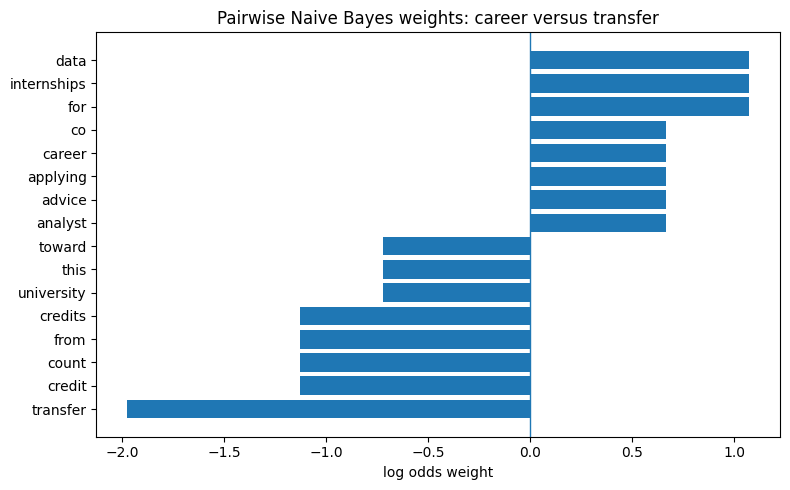

In [10]:
plot_df = pd.concat([comparison.head(8), comparison.tail(8)]).copy()
plot_df = plot_df.sort_values("log_odds_career_vs_transfer")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["token"], plot_df["log_odds_career_vs_transfer"])
plt.axvline(0, linewidth=1)
plt.xlabel("log odds weight")
plt.title("Pairwise Naive Bayes weights: career versus transfer")
plt.tight_layout()
plt.show()

## 12. Evaluation: confusion matrix and F1 score

Accuracy is the fraction of correct predictions. A confusion matrix shows which labels are confused with which other labels.

For a chosen positive class, define:

$$
\text{precision}=\frac{TP}{TP+FP},
$$

$$
\text{recall}=\frac{TP}{TP+FN},
$$

and

$$
F_1=\frac{2\cdot\text{precision}\cdot\text{recall}}{\text{precision}+\text{recall}}.
$$

In [11]:
def confusion_matrix_df(y_true, y_pred, labels):
    cm = pd.DataFrame(0, index=labels, columns=labels)
    for true, pred in zip(y_true, y_pred):
        cm.loc[true, pred] += 1
    cm.index.name = "true"
    cm.columns.name = "predicted"
    return cm

def precision_recall_f1_for_class(y_true, y_pred, positive_label):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    TP = np.sum((y_true == positive_label) & (y_pred == positive_label))
    FP = np.sum((y_true != positive_label) & (y_pred == positive_label))
    FN = np.sum((y_true == positive_label) & (y_pred != positive_label))
    precision = TP / (TP + FP) if TP + FP > 0 else 0.0
    recall = TP / (TP + FN) if TP + FN > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0.0
    return {"TP": TP, "FP": FP, "FN": FN, "precision": precision, "recall": recall, "f1": f1}

cm = confusion_matrix_df(test_labels, test_pred, model.classes_)
accuracy = np.mean(test_pred == test_labels)
print("Accuracy:", round(float(accuracy), 3))
display(cm)

metric_rows = []
for c in model.classes_:
    row = {"class": c}
    row.update(precision_recall_f1_for_class(test_labels, test_pred, c))
    metric_rows.append(row)

pd.DataFrame(metric_rows).round(3)

Accuracy: 1.0


predicted,career,registration,transfer
true,,,
career,2,0,0
registration,0,2,0
transfer,0,0,2


,class,TP,FP,FN,precision,recall,f1
0,career,2,0,0,1.0,1.0,1.0
1,registration,2,0,0,1.0,1.0,1.0
2,transfer,2,0,0,1.0,1.0,1.0


## 13. Smoothing experiment

The smoothing parameter $\alpha$ affects token probabilities and predictions. Smaller $\alpha$ trusts observed counts more. Larger $\alpha$ pulls each class distribution closer to uniform.

We will train the same model with several values of $\alpha$ and compare test accuracy and average log probability of the true label.

In [12]:
alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
rows = []
for alpha in alphas:
    m = MultinomialNaiveBayesScratch(alpha=alpha).fit(X_train, train_labels)
    pred = m.predict(X_test)
    log_proba = m.predict_log_proba(X_test)
    true_indices = np.array([list(m.classes_).index(y) for y in test_labels])
    avg_true_log_prob = np.mean(log_proba[np.arange(len(test_labels)), true_indices])
    rows.append({
        "alpha": alpha,
        "accuracy": np.mean(pred == test_labels),
        "avg_true_log_prob": avg_true_log_prob
    })

alpha_df = pd.DataFrame(rows)
alpha_df.round(4)

,alpha,accuracy,avg_true_log_prob
0,0.01,1.0,-0.0000
1,0.05,1.0,-0.0004
2,0.10,1.0,-0.0015
3,0.50,1.0,-0.0235
4,1.00,1.0,-0.0707
5,2.00,1.0,-0.1895
6,5.00,1.0,-0.4711


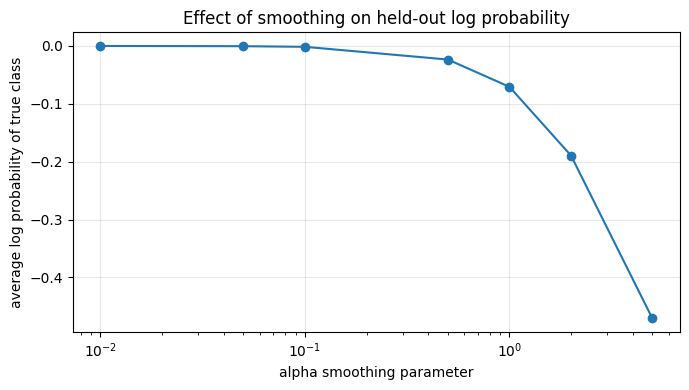

In [13]:
plt.figure(figsize=(7, 4))
plt.plot(alpha_df["alpha"], alpha_df["avg_true_log_prob"], marker="o")
plt.xscale("log")
plt.xlabel("alpha smoothing parameter")
plt.ylabel("average log probability of true class")
plt.title("Effect of smoothing on held-out log probability")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Try it yourself

Add a new ambiguous test question, such as:

```text
Can machine learning credits help with data science jobs
```

Vectorize it and inspect the predicted probabilities. Which class wins? Which tokens were responsible?

In [14]:
new_questions = [
    "Can machine learning credits help with data science jobs",
    "Do I need permission before I transfer a course",
    "Which projects help with quantitative internships",
]
X_new = vectorize(new_questions, token_to_index)
new_pred = model.predict(X_new)
new_prob = model.predict_proba(X_new)

new_rows = []
for i, q in enumerate(new_questions):
    row = {"question": q, "prediction": new_pred[i]}
    for k, c in enumerate(model.classes_):
        row[f"prob_{c}"] = new_prob[i, k]
    new_rows.append(row)

pd.DataFrame(new_rows).round(3)

,question,prediction,prob_career,prob_registration,prob_transfer
0,Can machine learning credits help with data science jobs,career,0.944,0.025,0.031
1,Do I need permission before I transfer a course,registration,0.003,0.966,0.031
2,Which projects help with quantitative internships,career,0.932,0.046,0.023


## 14. Unknown tokens and a special `<unk>` token

Our current vectorizer ignores test tokens that were not in the training vocabulary. This is common for simple baselines, but it means unseen words contribute no evidence.

Another approach is to reserve a special `<unk>` token. Rare training words are mapped to `<unk>`, and unseen test words are also mapped to `<unk>`. This makes unknown-word behavior explicit.

In [15]:
def build_vocabulary_with_unk(texts, min_count=2):
    counts = Counter(tok for text in texts for tok in tokenize(text))
    vocab = ["<unk>"] + sorted([tok for tok, count in counts.items() if count >= min_count])
    token_to_index = {tok: j for j, tok in enumerate(vocab)}
    return vocab, token_to_index, counts

def vectorize_with_unk(texts, token_to_index):
    X = np.zeros((len(texts), len(token_to_index)), dtype=float)
    unk_index = token_to_index["<unk>"]
    for i, text in enumerate(texts):
        for tok in tokenize(text):
            j = token_to_index.get(tok, unk_index)
            X[i, j] += 1.0
    return X

vocab_unk, token_to_index_unk, counts_unk = build_vocabulary_with_unk(train_texts, min_count=2)
X_train_unk = vectorize_with_unk(train_texts, token_to_index_unk)
X_test_unk = vectorize_with_unk(test_texts, token_to_index_unk)

model_unk = MultinomialNaiveBayesScratch(alpha=1.0).fit(X_train_unk, train_labels)
pred_unk = model_unk.predict(X_test_unk)

print("Vocabulary with <unk> size:", len(vocab_unk))
print("Vocabulary:", vocab_unk)
print("Accuracy with <unk> vocabulary:", round(float(np.mean(pred_unk == test_labels)), 3))

pd.DataFrame({"text": test_texts, "true": test_labels, "pred_without_unk": test_pred, "pred_with_unk": pred_unk})

Vocabulary with <unk> size: 29
Vocabulary: ['<unk>', 'a', 'are', 'before', 'can', 'count', 'course', 'courses', 'credit', 'credits', 'data', 'do', 'does', 'for', 'from', 'how', 'i', 'internships', 'learning', 'machine', 'my', 'need', 'probability', 'the', 'this', 'to', 'transfer', 'want', 'what']
Accuracy with <unk> vocabulary: 0.833


,text,true,pred_without_unk,pred_with_unk
0,Can my previous college probability course transfer,transfer,transfer,transfer
1,How do I enroll in machine learning if the class is full,registration,registration,registration
2,What projects should I put in a data science portfolio,career,career,career
3,Do transfer credits require official documents,transfer,transfer,transfer
4,Which prerequisite is required for stochastic processes,registration,registration,career
5,How do I find internships for quantitative roles,career,career,career


## 15. Bernoulli Naive Bayes idea

Multinomial Naive Bayes uses counts. Bernoulli Naive Bayes uses binary presence features:

$$
z_j=1 \quad \text{if token } v_j \text{ appears in the document},
$$

and $z_j=0$ otherwise.

The Bernoulli model can be useful when repetition should not count as repeated independent evidence. We will not fully implement the Bernoulli model here, but we can compare count features and binary features using the same scratch multinomial code as a practical experiment.

In [16]:
X_train_binary = (X_train > 0).astype(float)
X_test_binary = (X_test > 0).astype(float)

binary_feature_model = MultinomialNaiveBayesScratch(alpha=1.0).fit(X_train_binary, train_labels)
binary_pred = binary_feature_model.predict(X_test_binary)

pd.DataFrame({
    "text": test_texts,
    "true": test_labels,
    "count_feature_pred": test_pred,
    "binary_feature_pred": binary_pred
})

,text,true,count_feature_pred,binary_feature_pred
0,Can my previous college probability course transfer,transfer,transfer,transfer
1,How do I enroll in machine learning if the class is full,registration,registration,registration
2,What projects should I put in a data science portfolio,career,career,career
3,Do transfer credits require official documents,transfer,transfer,transfer
4,Which prerequisite is required for stochastic processes,registration,registration,registration
5,How do I find internships for quantitative roles,career,career,career


## 16. Comparison with scikit-learn

The scratch implementation is useful for learning. In real projects, we usually use tested library implementations. The next cell compares our model with `scikit-learn`'s `MultinomialNB`.

In [17]:
try:
    from sklearn.naive_bayes import MultinomialNB
    from sklearn.linear_model import LogisticRegression
    from sklearn.pipeline import make_pipeline
    from sklearn.feature_extraction.text import CountVectorizer

    sklearn_nb = MultinomialNB(alpha=1.0)
    sklearn_nb.fit(X_train, train_labels)
    sklearn_pred = sklearn_nb.predict(X_test)

    compare_df = pd.DataFrame({
        "text": test_texts,
        "true": test_labels,
        "scratch_pred": test_pred,
        "sklearn_nb_pred": sklearn_pred
    })
    display(compare_df)

    print("Scratch accuracy:", round(float(np.mean(test_pred == test_labels)), 3))
    print("sklearn NB accuracy:", round(float(np.mean(sklearn_pred == test_labels)), 3))
except Exception as e:
    print("scikit-learn comparison skipped:", repr(e))

,text,true,scratch_pred,sklearn_nb_pred
0,Can my previous college probability course transfer,transfer,transfer,transfer
1,How do I enroll in machine learning if the class is full,registration,registration,registration
2,What projects should I put in a data science portfolio,career,career,career
3,Do transfer credits require official documents,transfer,transfer,transfer
4,Which prerequisite is required for stochastic processes,registration,registration,registration
5,How do I find internships for quantitative roles,career,career,career


Scratch accuracy: 1.0
sklearn NB accuracy: 1.0


## 17. Naive Bayes versus logistic regression

Naive Bayes is a **generative** classifier. It estimates

$$
P(Y=c) \quad \text{and} \quad P(X=x \mid Y=c).
$$

Logistic regression is a **discriminative** classifier. It estimates

$$
P(Y=c \mid X=x)
$$

directly.

Both can produce linear decision rules in count-vector space, but they are trained using different principles.

In [18]:
try:
    logreg = LogisticRegression(max_iter=1000)
    logreg.fit(X_train, train_labels)
    logreg_pred = logreg.predict(X_test)

    pd.DataFrame({
        "text": test_texts,
        "true": test_labels,
        "naive_bayes": test_pred,
        "logistic_regression": logreg_pred
    })
except Exception as e:
    print("Logistic regression comparison skipped:", repr(e))

## 18. Error analysis and model auditing

Naive Bayes is useful partly because it is inspectable. Good model auditing asks:

1. Which examples were misclassified?
2. Which tokens caused the prediction?
3. Are large feature weights semantically meaningful?
4. Are any features suspicious artifacts of the dataset?
5. Does the validation set resemble the deployment setting?

On this tiny test set the model may perform very well, but the same analysis matters for larger datasets.

In [19]:
error_rows = []
for i, text in enumerate(test_texts):
    if test_pred[i] != test_labels[i]:
        error_rows.append({"text": text, "true": test_labels[i], "pred": test_pred[i]})

if error_rows:
    display(pd.DataFrame(error_rows))
else:
    print("No errors on this small test set. Add harder examples below to practice error analysis.")

hard_examples = [
    ("Can I transfer into a data science internship course", "transfer"),
    ("Is the registration deadline important for co op", "registration"),
    ("Will transfer credit improve my career plan", "career"),
]
X_hard = vectorize([x for x, y in hard_examples], token_to_index)
hard_pred = model.predict(X_hard)
hard_prob = model.predict_proba(X_hard)

hard_df = pd.DataFrame({
    "text": [x for x, y in hard_examples],
    "suggested_true_label": [y for x, y in hard_examples],
    "prediction": hard_pred
})
for k, c in enumerate(model.classes_):
    hard_df[f"prob_{c}"] = hard_prob[:, k]

hard_df.round(3)

No errors on this small test set. Add harder examples below to practice error analysis.


,text,suggested_true_label,prediction,prob_career,prob_registration,prob_transfer
0,Can I transfer into a data science internship course,transfer,transfer,0.208,0.063,0.730
1,Is the registration deadline important for co op,registration,registration,0.339,0.595,0.066
2,Will transfer credit improve my career plan,career,transfer,0.077,0.021,0.901


## 19. A small reusable prediction function

For independent study, it is helpful to package the full prediction pipeline into one function.

In [20]:
def classify_questions(questions, model=model, token_to_index=token_to_index):
    X = vectorize(questions, token_to_index)
    pred = model.predict(X)
    prob = model.predict_proba(X)
    rows = []
    for i, q in enumerate(questions):
        row = {"question": q, "prediction": pred[i]}
        for k, c in enumerate(model.classes_):
            row[f"prob_{c}"] = prob[i, k]
        rows.append(row)
    return pd.DataFrame(rows)

classify_questions([
    "I need advice about resume projects and jobs",
    "Can my online course count as transfer credit",
    "When can I join the waitlist for statistical learning",
]).round(3)

,question,prediction,prob_career,prob_registration,prob_transfer
0,I need advice about resume projects and jobs,career,0.835,0.141,0.024
1,Can my online course count as transfer credit,transfer,0.001,0.001,0.998
2,When can I join the waitlist for statistical learning,registration,0.021,0.968,0.011


## 20. AI-assisted model-auditing exercise

Use an AI tool as a critic, not as a replacement for your own analysis. You can copy the top positive and negative tokens from this notebook and ask:

```text
I trained a multinomial Naive Bayes classifier for student questions.
The classes are transfer, registration, and career.
Here are high-weight tokens for one pairwise comparison: ...
Which tokens seem semantically meaningful?
Which tokens may indicate a dataset artifact or leakage?
Explain in a table.
```

Then check the answer against the actual training examples. A strong audit should distinguish meaningful signals from accidental patterns.

Do not paste private student records or sensitive institutional data into an external AI tool. Use synthetic or anonymized examples.

## 21. Exercises

1. **Bayes rule.** Starting from Bayes' theorem, derive
   $$
   \widehat y=\arg\max_c P(X=x\mid Y=c)P(Y=c).
   $$

2. **Count vector.** For the sentence `transfer credit course transfer`, write the count vector using the vocabulary `credit`, `course`, `transfer`.

3. **Smoothing.** Suppose a class has $N_c=100$ total tokens, vocabulary size $m=20$, and token count $N_{cj}=0$. Compute the smoothed probability when $\alpha=1$.

4. **Log-score.** Explain why log-scores are better than multiplying probabilities directly.

5. **Feature interpretation.** If
   $$
   \log\frac{\theta_{career,j}}{\theta_{transfer,j}}=2,
   $$
   what is the approximate ratio $\theta_{career,j}/\theta_{transfer,j}$?

6. **Model assumption.** Give one example where the conditional independence assumption is false in natural language.

7. **Smoothing experiment.** Try $\alpha=0.01$, $\alpha=0.1$, $\alpha=1$, and $\alpha=10$. Which value gives the best held-out log probability in this notebook?

8. **Unknown tokens.** Explain the difference between ignoring unknown tokens and mapping them to `<unk>`.

9. **Binary features.** Convert the count matrix to binary features. Which predictions change?

10. **Error analysis.** Create five harder examples that mix vocabulary from multiple classes. Inspect the predicted probabilities and write a short explanation for each result.

## 22. Mini-project: transparent text classifier

Build your own Naive Bayes text classifier for a small dataset. You may use synthetic examples or a public dataset.

Your report should include:

1. the task and label set;
2. a description of the dataset;
3. the tokenization rule;
4. the vocabulary size;
5. the mathematical form of the Naive Bayes model;
6. the smoothing value $\alpha$;
7. a confusion matrix;
8. precision, recall, and F1 score for at least one class;
9. the top positive and negative log-odds tokens for one pair of classes;
10. at least three examples of error analysis;
11. one paragraph comparing Naive Bayes with a more modern NLP model.

A good mini-project emphasizes transparency: you should be able to explain why the model made each prediction.

## 23. Summary

In this lab, you learned how to turn Bayes' theorem into a working text classifier.

The core pipeline was:

$$
\text{text} \rightarrow \text{tokens} \rightarrow \text{count vectors} \rightarrow \widehat\pi_c,\widehat\theta_{cj} \rightarrow \text{log-scores} \rightarrow \text{predictions}.
$$

Key ideas:

- Naive Bayes is a generative model for text classification.
- Count vectors make documents into numerical objects.
- Add-alpha smoothing prevents zero probabilities.
- Log-scores make computation stable.
- Pairwise log-odds weights make the model interpretable.
- Evaluation requires more than accuracy: inspect confusion matrices, class-level metrics, feature weights, and errors.